In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
BETTI_CSV_PATH = "amfizem_ct_betti_features_bins50.csv"

df = pd.read_csv(BETTI_CSV_PATH)

df["binary_label"] = df["class_name"].apply(
    lambda x: 0 if x == "Normal" else 1
)

binary_class_names = ["Normal", "Emphysema"]

print(df.shape)
print(df["class_name"].value_counts())
print(df["binary_label"].value_counts())

(1108, 405)
class_name
Normal          329
Panlobular      262
Paraseptal      259
Centroacinar    258
Name: count, dtype: int64
binary_label
1    779
0    329
Name: count, dtype: int64


In [4]:
meta_cols = ["image_name", "image_path", "class_name", "label", "binary_label"]
betti_cols = [c for c in df.columns if c not in meta_cols]

print("Betti feature sayısı:", len(betti_cols))

Betti feature sayısı: 400


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["binary_label"],
    random_state=42
)

print("Train:", train_df.shape)
print(train_df["binary_label"].value_counts())

print("Val:", val_df.shape)
print(val_df["binary_label"].value_counts())

print("Test:", test_df.shape)
print(test_df["binary_label"].value_counts())

Train: (775, 405)
binary_label
1    545
0    230
Name: count, dtype: int64
Val: (166, 405)
binary_label
1    117
0     49
Name: count, dtype: int64
Test: (167, 405)
binary_label
1    117
0     50
Name: count, dtype: int64


In [7]:
scaler = StandardScaler()

train_betti = scaler.fit_transform(train_df[betti_cols].values)
val_betti = scaler.transform(val_df[betti_cols].values)
test_betti = scaler.transform(test_df[betti_cols].values)

In [8]:
IMG_SIZE = 518

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class EmphysemaBinaryFusionDataset(Dataset):
    def __init__(self, dataframe, betti_array, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.betti = betti_array.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "binary_label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        betti = torch.tensor(self.betti[idx], dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return image, betti, label

In [10]:
BATCH_SIZE = 8

train_dataset = EmphysemaBinaryFusionDataset(train_df, train_betti, train_transform)
val_dataset = EmphysemaBinaryFusionDataset(val_df, val_betti, eval_transform)
test_dataset = EmphysemaBinaryFusionDataset(test_df, test_betti, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
class TopologyImageCrossAttentionModel(nn.Module):
    def __init__(
        self,
        betti_dim,
        num_classes=2,
        backbone_name="vit_small_patch14_dinov2",
        pretrained=True,
        freeze_backbone=True,
        attn_heads=4,
        dropout=0.35
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0
        )

        self.embed_dim = self.backbone.num_features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.topology_encoder = nn.Sequential(
            nn.Linear(betti_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, self.embed_dim),
            nn.LayerNorm(self.embed_dim)
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=self.embed_dim,
            num_heads=attn_heads,
            dropout=dropout,
            batch_first=True
        )

        self.fusion_norm = nn.LayerNorm(self.embed_dim * 3)

        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim * 3, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def get_image_tokens(self, x):
        tokens = self.backbone.forward_features(x)

        if isinstance(tokens, dict):
            if "x_norm_patchtokens" in tokens:
                patch_tokens = tokens["x_norm_patchtokens"]
                cls_token = tokens["x_norm_clstoken"]
                return cls_token, patch_tokens
            else:
                tokens = list(tokens.values())[0]

        if tokens.dim() == 3:
            cls_token = tokens[:, 0]
            patch_tokens = tokens[:, 1:]
        else:
            cls_token = tokens
            patch_tokens = tokens.unsqueeze(1)

        return cls_token, patch_tokens

    def forward(self, image, betti):
        cls_token, patch_tokens = self.get_image_tokens(image)

        topo_token = self.topology_encoder(betti)
        topo_query = topo_token.unsqueeze(1)

        attended_topo, _ = self.cross_attention(
            query=topo_query,
            key=patch_tokens,
            value=patch_tokens
        )

        attended_topo = attended_topo.squeeze(1)

        fusion = torch.cat(
            [cls_token, topo_token, attended_topo],
            dim=1
        )

        fusion = self.fusion_norm(fusion)
        logits = self.classifier(fusion)

        return logits

In [12]:
model = TopologyImageCrossAttentionModel(
    betti_dim=len(betti_cols),
    num_classes=2,
    backbone_name="vit_small_patch14_dinov2",
    pretrained=True,
    freeze_backbone=True,
    attn_heads=4,
    dropout=0.35
).to(device)

In [13]:
class_counts = train_df["binary_label"].value_counts().sort_index().values

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

Class counts: [230 545]
Class weights: tensor([0.7032, 0.2968], device='cuda:0')


In [14]:
def train_one_epoch(model, loader, optimizer, criterion, grad_clip=1.0):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []

    for images, betti, labels in loader:
        images = images.to(device)
        betti = betti.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images, betti)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=grad_clip
        )

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    emphysema_f1 = f1_score(all_labels, all_preds, pos_label=1)

    return total_loss / len(loader), acc, bal_acc, macro_f1, emphysema_f1

In [15]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, betti, labels in loader:
            images = images.to(device)
            betti = betti.to(device)
            labels = labels.to(device)

            logits = model(images, betti)
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    emphysema_f1 = f1_score(all_labels, all_preds, pos_label=1)

    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)

    return (
        total_loss / len(loader),
        acc,
        bal_acc,
        macro_f1,
        emphysema_f1,
        roc_auc,
        pr_auc,
        all_labels,
        all_preds,
        all_probs
    )

In [16]:
EPOCHS = 100
PATIENCE = 5
MIN_DELTA = 1e-4

best_val_f1 = 0
best_epoch = 0
epochs_without_improvement = 0

best_model_path = "best_binary_dinov2.pth"
best_model_wts = copy.deepcopy(model.state_dict())

history = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_bal_acc, train_macro_f1, train_emphysema_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        grad_clip=1.0
    )

    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_macro_f1,
        val_emphysema_f1,
        val_roc_auc,
        val_pr_auc,
        _,
        _,
        _
    ) = evaluate(model, val_loader, criterion)

    scheduler.step(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch + 1,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_bal_acc": train_bal_acc,
        "train_macro_f1": train_macro_f1,
        "train_emphysema_f1": train_emphysema_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_bal_acc": val_bal_acc,
        "val_macro_f1": val_macro_f1,
        "val_emphysema_f1": val_emphysema_f1,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc
    })

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"LR: {current_lr:.2e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Macro-F1: {train_macro_f1:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Val Bal-Acc: {val_bal_acc:.4f} | "
        f"Val ROC-AUC: {val_roc_auc:.4f}"
    )

    if val_macro_f1 > best_val_f1 + MIN_DELTA:
        best_val_f1 = val_macro_f1
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), best_model_path)

        print(f"Best model saved. Epoch: {best_epoch}, Val Macro-F1: {best_val_f1:.4f}")

    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        print(f"Best epoch: {best_epoch}")
        print(f"Best Val Macro-F1: {best_val_f1:.4f}")
        break

Epoch [1/100] | LR: 1.00e-04 | Train Loss: 0.5354 | Val Loss: 0.3868 | Train Macro-F1: 0.7403 | Val Macro-F1: 0.8218 | Val Bal-Acc: 0.8609 | Val ROC-AUC: 0.9534
Best model saved. Epoch: 1, Val Macro-F1: 0.8218
Epoch [2/100] | LR: 1.00e-04 | Train Loss: 0.4136 | Val Loss: 0.3046 | Train Macro-F1: 0.8177 | Val Macro-F1: 0.9151 | Val Bal-Acc: 0.9250 | Val ROC-AUC: 0.9785
Best model saved. Epoch: 2, Val Macro-F1: 0.9151
Epoch [3/100] | LR: 1.00e-04 | Train Loss: 0.3487 | Val Loss: 0.2805 | Train Macro-F1: 0.8910 | Val Macro-F1: 0.9168 | Val Bal-Acc: 0.9369 | Val ROC-AUC: 0.9852
Best model saved. Epoch: 3, Val Macro-F1: 0.9168
Epoch [4/100] | LR: 1.00e-04 | Train Loss: 0.2917 | Val Loss: 0.2585 | Train Macro-F1: 0.9163 | Val Macro-F1: 0.9428 | Val Bal-Acc: 0.9480 | Val ROC-AUC: 0.9901
Best model saved. Epoch: 4, Val Macro-F1: 0.9428
Epoch [5/100] | LR: 1.00e-04 | Train Loss: 0.3080 | Val Loss: 0.2622 | Train Macro-F1: 0.9113 | Val Macro-F1: 0.9300 | Val Bal-Acc: 0.9454 | Val ROC-AUC: 0.9890

In [17]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

(
    test_loss,
    test_acc,
    test_bal_acc,
    test_macro_f1,
    test_emphysema_f1,
    test_roc_auc,
    test_pr_auc,
    y_true,
    y_pred,
    y_prob
) = evaluate(model, test_loader, criterion)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Balanced Accuracy:", test_bal_acc)
print("Test Macro F1:", test_macro_f1)
print("Test Emphysema F1:", test_emphysema_f1)
print("Test ROC-AUC:", test_roc_auc)
print("Test PR-AUC:", test_pr_auc)

print(classification_report(
    y_true,
    y_pred,
    target_names=binary_class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)
cm

Test Loss: 0.2240184588091714
Test Accuracy: 0.9461077844311377
Test Balanced Accuracy: 0.9558119658119658
Test Macro F1: 0.9381201366873895
Test Emphysema F1: 0.960352422907489
Test ROC-AUC: 0.9941880341880341
Test PR-AUC: 0.9975557611570252
              precision    recall  f1-score   support

      Normal     0.8596    0.9800    0.9159        50
   Emphysema     0.9909    0.9316    0.9604       117

    accuracy                         0.9461       167
   macro avg     0.9253    0.9558    0.9381       167
weighted avg     0.9516    0.9461    0.9470       167



array([[ 49,   1],
       [  8, 109]])

In [18]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
npv = tn / (tn + fn)

print("Sensitivity / Recall:", sensitivity)
print("Specificity:", specificity)
print("Precision / PPV:", precision)
print("NPV:", npv)

Sensitivity / Recall: 0.9316239316239316
Specificity: 0.98
Precision / PPV: 0.990909090909091
NPV: 0.8596491228070176


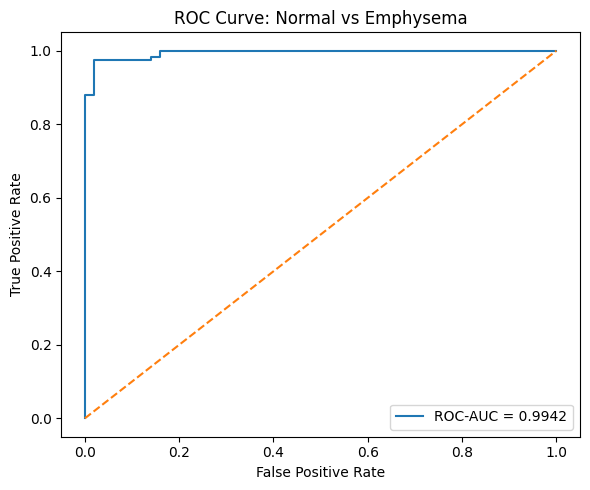

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Normal vs Emphysema")
plt.legend()
plt.tight_layout()
plt.savefig("binary_roc_curve.png", dpi=300)
plt.show()

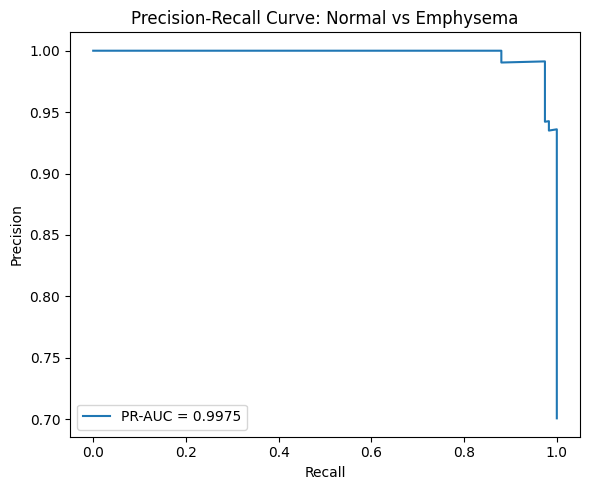

In [20]:
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Normal vs Emphysema")
plt.legend()
plt.tight_layout()
plt.savefig("b_pr_curve.png", dpi=300)
plt.show()

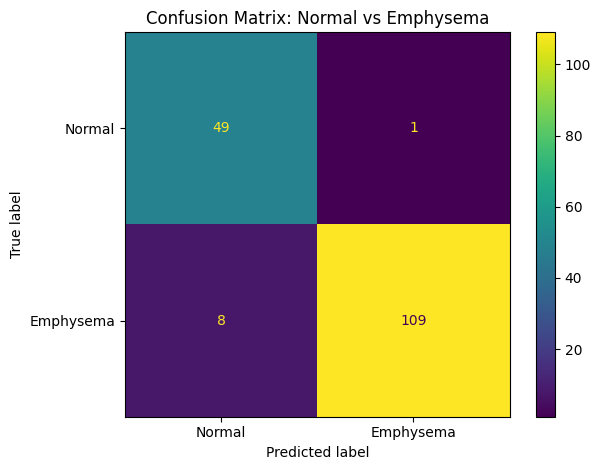

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=binary_class_names
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: Normal vs Emphysema")
plt.tight_layout()
plt.savefig("b_confusion_matrix.png", dpi=300)
plt.show()

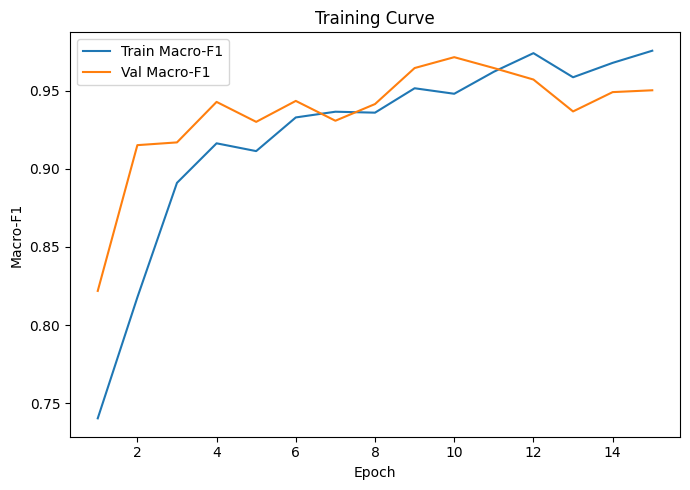

In [22]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("binary_train_macro_f1.png", dpi=300)
plt.show()

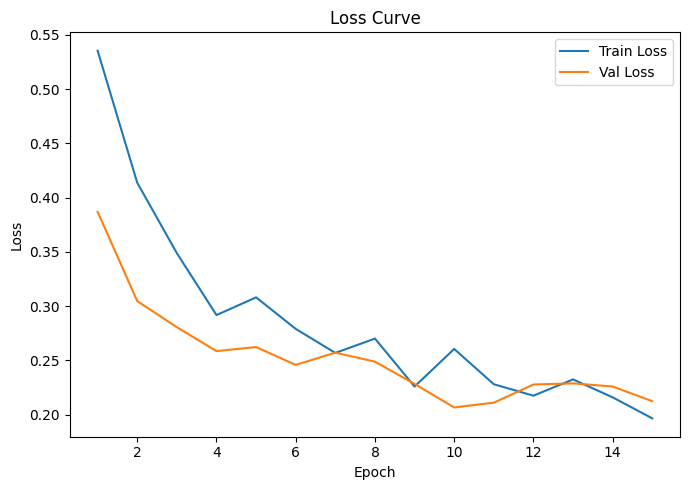

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("binary_train_loss.png", dpi=300)
plt.show()